In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [23]:
df = load_iris()

In [24]:
df

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [25]:
df.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [26]:
df.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [27]:
X = df.data
y = df.target

In [28]:
X = pd.DataFrame(X, columns=['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)'])

In [29]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [30]:
y = pd.DataFrame(y, columns=["target"])

In [31]:
y.head()

,target
0,0
1,0
2,0
3,0
4,0


In [32]:
df = pd.concat([X, y], axis=1)

In [33]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [34]:
# Two make it more difficult classification we only incude "sepal width and petal length" and from target only two categories 1, 2
# 0: Iris-setosa
# 1: Iris-versicolor
# 2: Iris-virginica

In [40]:
df = df[df["target"] != 0][["sepal width (cm)", "petal length (cm)", "target"]]

In [41]:
df.head(3)

,sepal width (cm),petal length (cm),target
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1


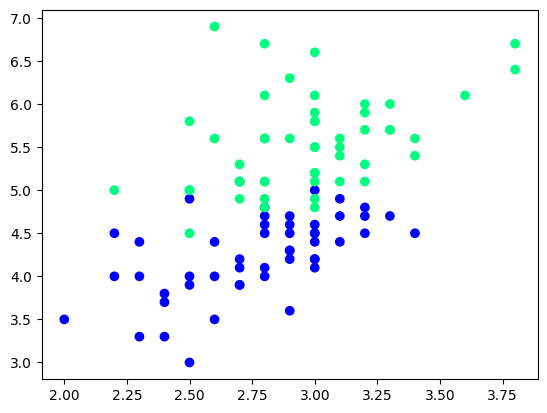

In [44]:
plt.scatter(df["sepal width (cm)"], df["petal length (cm)"], c = df["target"], cmap="winter")
plt.show()

In [53]:
# Now we will take samples as training, validation and testing sets

df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80, :].sample(5)
df_test = df.iloc[80:, :].sample(5)

In [54]:
df

,sepal width (cm),petal length (cm),target
93,2.3,3.3,1
145,3.0,5.2,2
72,2.5,4.9,1
112,3.0,5.5,2
105,3.0,6.6,2
...,...,...,...
121,2.8,4.9,2
134,2.6,5.6,2
89,2.5,4.0,1
125,3.2,6.0,2


In [55]:
df_train

,sepal width (cm),petal length (cm),target
87,2.3,4.4,1
103,2.9,5.6,2
111,2.7,5.3,2
118,2.6,6.9,2
55,2.8,4.5,1
64,2.9,3.6,1
74,2.9,4.3,1
63,2.9,4.7,1
117,3.8,6.7,2
109,3.6,6.1,2


In [56]:
df_val

,sepal width (cm),petal length (cm),target
149,3.0,5.1,2
62,2.2,4.0,1
51,3.2,4.5,1
70,3.2,4.8,1
85,3.4,4.5,1


In [57]:
df_test

,sepal width (cm),petal length (cm),target
138,3.0,4.8,2
95,3.0,4.2,1
56,3.3,4.7,1
101,2.7,5.1,2
106,2.5,4.5,2


In [58]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,2].values

In [60]:
X_test, y_test

(array([[3. , 5.1],
        [2.2, 4. ],
        [3.2, 4.5],
        [3.2, 4.8],
        [3.4, 4.5]]),
 array([2, 1, 1, 1, 1]))

## Case 1 - Bagging

In [98]:
# Data For Tree 1
df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[:, 0:2].values
y = df_bag.iloc[:,2].values

df_bag

,sepal width (cm),petal length (cm),target
64,2.9,3.6,1
103,2.9,5.6,2
74,2.9,4.3,1
87,2.3,4.4,1
118,2.6,6.9,2
63,2.9,4.7,1
103,2.9,5.6,2
103,2.9,5.6,2


In [99]:
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [100]:
dt_bag1 = DecisionTreeClassifier()

In [101]:
def evaluate(clf, X, y):
    clf.fit(X, y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X, y, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print("Accuracy Score: ", accuracy_score(y_test, y_pred))

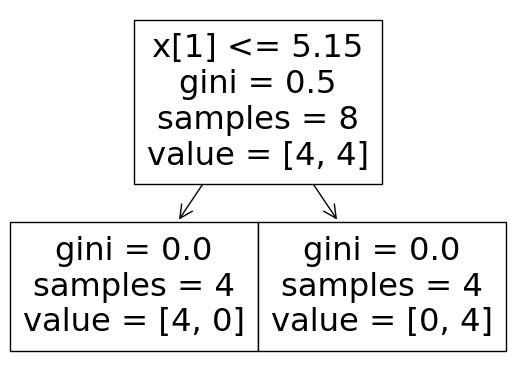

Accuracy Score:  0.8


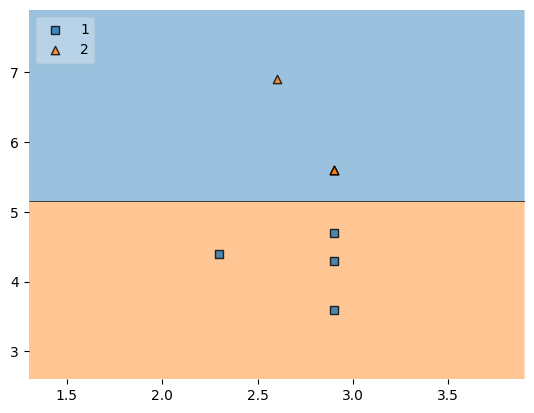

In [102]:
evaluate(dt_bag1, X, y)

In [103]:
df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[:, 0:2].values
y = df_bag.iloc[:,2].values

df_bag


,sepal width (cm),petal length (cm),target
55,2.8,4.5,1
117,3.8,6.7,2
111,2.7,5.3,2
111,2.7,5.3,2
74,2.9,4.3,1
64,2.9,3.6,1
87,2.3,4.4,1
118,2.6,6.9,2


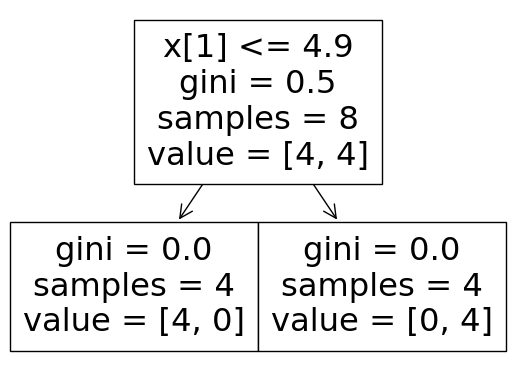

Accuracy Score:  1.0


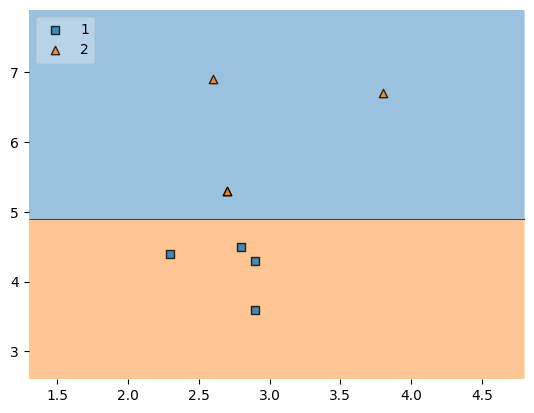

In [104]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2, X, y)

In [105]:
df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[:, 0:2].values
y = df_bag.iloc[:,2].values

df_bag

,sepal width (cm),petal length (cm),target
111,2.7,5.3,2
63,2.9,4.7,1
63,2.9,4.7,1
109,3.6,6.1,2
87,2.3,4.4,1
55,2.8,4.5,1
118,2.6,6.9,2
55,2.8,4.5,1


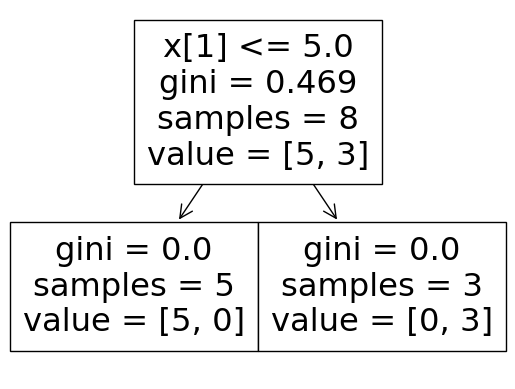

Accuracy Score:  1.0


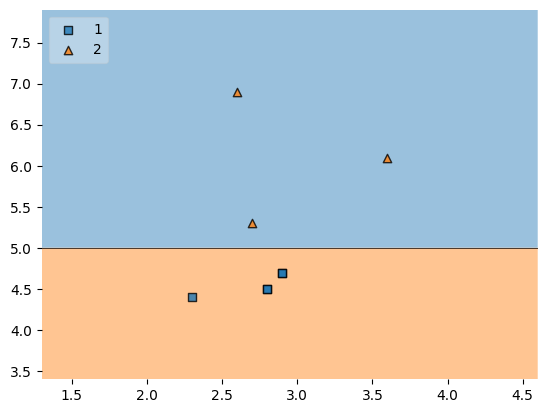

In [106]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3, X, y)

## Predict

In [107]:
df_test

,sepal width (cm),petal length (cm),target
138,3.0,4.8,2
95,3.0,4.2,1
56,3.3,4.7,1
101,2.7,5.1,2
106,2.5,4.5,2


In [109]:
print("Predictor 1: ", dt_bag1.predict(np.array([2.7, 5.1]).reshape(1,2)))
print("Predictor 2: ", dt_bag2.predict(np.array([2.7, 5.1]).reshape(1,2)))
print("Predictor 3: ", dt_bag3.predict(np.array([2.7, 5.1]).reshape(1,2)))

Predictor 1:  [1]
Predictor 2:  [2]
Predictor 3:  [2]


## Types of Bagging

## Pasting

In [110]:
# "pasting" refers to a technique similar to bagging but without replacement.

In [111]:
# Row Sampling without Replacement
df_train

,sepal width (cm),petal length (cm),target
87,2.3,4.4,1
103,2.9,5.6,2
111,2.7,5.3,2
118,2.6,6.9,2
55,2.8,4.5,1
64,2.9,3.6,1
74,2.9,4.3,1
63,2.9,4.7,1
117,3.8,6.7,2
109,3.6,6.1,2


In [112]:
df_train.sample(8)

,sepal width (cm),petal length (cm),target
87,2.3,4.4,1
118,2.6,6.9,2
63,2.9,4.7,1
111,2.7,5.3,2
55,2.8,4.5,1
64,2.9,3.6,1
117,3.8,6.7,2
109,3.6,6.1,2


## Random SubSpaces

In [113]:
# subspaces involve sampling features (columns) to train each base model on a different subset of features.

In [117]:
df

,sepal width (cm),petal length (cm),target
93,2.3,3.3,1
145,3.0,5.2,2
72,2.5,4.9,1
112,3.0,5.5,2
105,3.0,6.6,2
...,...,...,...
121,2.8,4.9,2
134,2.6,5.6,2
89,2.5,4.0,1
125,3.2,6.0,2


In [124]:
df.sample(2, replace=True, axis=1)

,target,sepal width (cm)
93,1,2.3
145,2,3.0
72,1,2.5
112,2,3.0
105,2,3.0
...,...,...
121,2,2.8
134,2,2.6
89,1,2.5
125,2,3.2


## Random Patches

In [125]:
# combines elements of both random subspaces (feature sampling) and bagging (instance sampling). 

In [126]:
df.sample(2, replace=True)

,sepal width (cm),petal length (cm),target
93,2.3,3.3,1
51,3.2,4.5,1
